In [1]:
# Import the necessary tools for making a Wulff shape
from pymatgen.analysis.wulff import WulffShape

# Import the necessary tools to generate surfaces
from pymatgen.core.surface import Lattice, SlabGenerator, Structure, generate_all_slabs

In [2]:
from pymatgen.ext.matproj import MPRester
import requests

api_key = "sQVD5i18g58Znx0RQfu0ZzshJUSx9tmI"
mpr = MPRester(api_key)


/Users/vkolluru/miniconda3/envs/MyEnv2/lib/python3.11/site-packages/mp_api/client/mprester.py:182: UserWarning: mpcontribs-client not installed. Install the package to query MPContribs data, or construct pourbaix diagrams: 'pip install mpcontribs-client'
  warnings.warn(


In [7]:
from pymatgen.core import Lattice, Structure

# Define the lattice constant for fcc platinum and structure

lattice = Lattice.cubic(3.924)
pt_structure = Structure(
    lattice,
    ["Pt", "Pt", "Pt", "Pt"],
    [[0, 0, 0], [0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]],
)


In [8]:
slabgen = SlabGenerator(pt_structure, (1, 1, 1), 10, 10)

all_slabs = slabgen.get_slabs()
print("The Pt(111) slab only has %s termination." % (len(all_slabs)))

The Pt(111) slab only has 1 termination.


In [9]:
all_slabs = generate_all_slabs(pt_structure, 3, 10, 10)
print(
    "%s unique slab structures have been found for a max Miller index of 3"
    % (len(all_slabs)))

13 unique slab structures have been found for a max Miller index of 3


In [10]:


# What are the Miller indices of these slabs?
for slab in all_slabs:
    print(slab.miller_index)
print(
    "Notice some Miller indices are repeated. Again, this is due to there being more than one termination"
)



(1, 1, 1)
(1, 1, 0)
(1, 0, 0)
(2, 2, 1)
(2, 1, 1)
(2, 1, 0)
(3, 3, 2)
(3, 3, 1)
(3, 2, 2)
(3, 2, 1)
(3, 2, 0)
(3, 1, 1)
(3, 1, 0)
Notice some Miller indices are repeated. Again, this is due to there being more than one termination


shape factor: 5.390, anisotropy: 0.085, weighted surface energy: 1.543 J/m^2


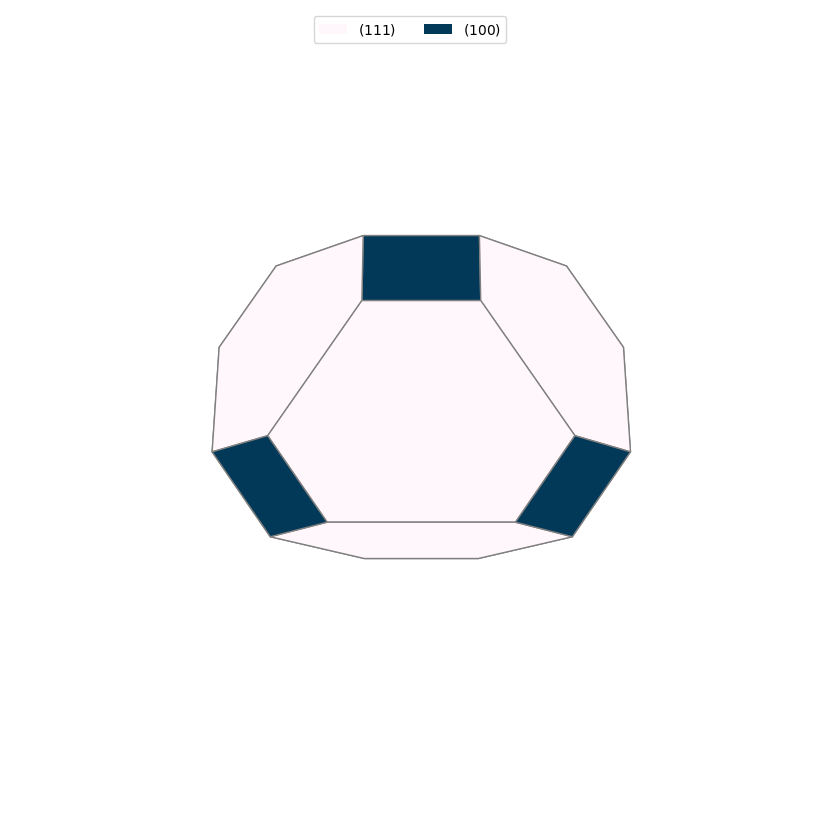

In [11]:

# Replace "Pt" with the correct formula for platinum, e.g., "Pt" or "mp-78" (Materials Project ID)
surface_energies_Pt = {(1, 1, 1):1.488,
(1, 0, 0):1.856} #Jm-2

miller_list = surface_energies_Pt.keys()
e_surf_list = surface_energies_Pt.values()
# We can now construct a Wulff shape with an accuracy up to a max Miller index of 3
wulffshape = WulffShape(Pt.lattice, miller_list, e_surf_list)

# Let's get some useful information from our wulffshape object
print(
    "shape factor: %.3f, anisotropy: \
%.3f, weighted surface energy: %.3f J/m^2"
    % (
        wulffshape.shape_factor,
        wulffshape.anisotropy,
        wulffshape.weighted_surface_energy,
    )
)


# If we want to see what our Wulff shape looks like
wulffshape.show()


In [ ]:
wulffshape.